# Jittered models and performance on diff trial types

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-08-12 12:37:23.972509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 12:37:23.981611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-12 12:37:23.990826: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-12 12:37:23.993562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-12 12:37:24.001678: I tensorflow/core/platform/cpu_feature_guar

### delay 150

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [4]:
model_dirs

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_184512',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_193702',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_162650',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194942',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_182548',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_183522',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_200122',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185141',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_163652',
 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_190924']

In [5]:
# get all of the jittered models and their performances
importlib.reload(ld)
jittered_models, jittered_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              all_models_dir = all_models_dir)


Found 15 models with performance between -inf and inf


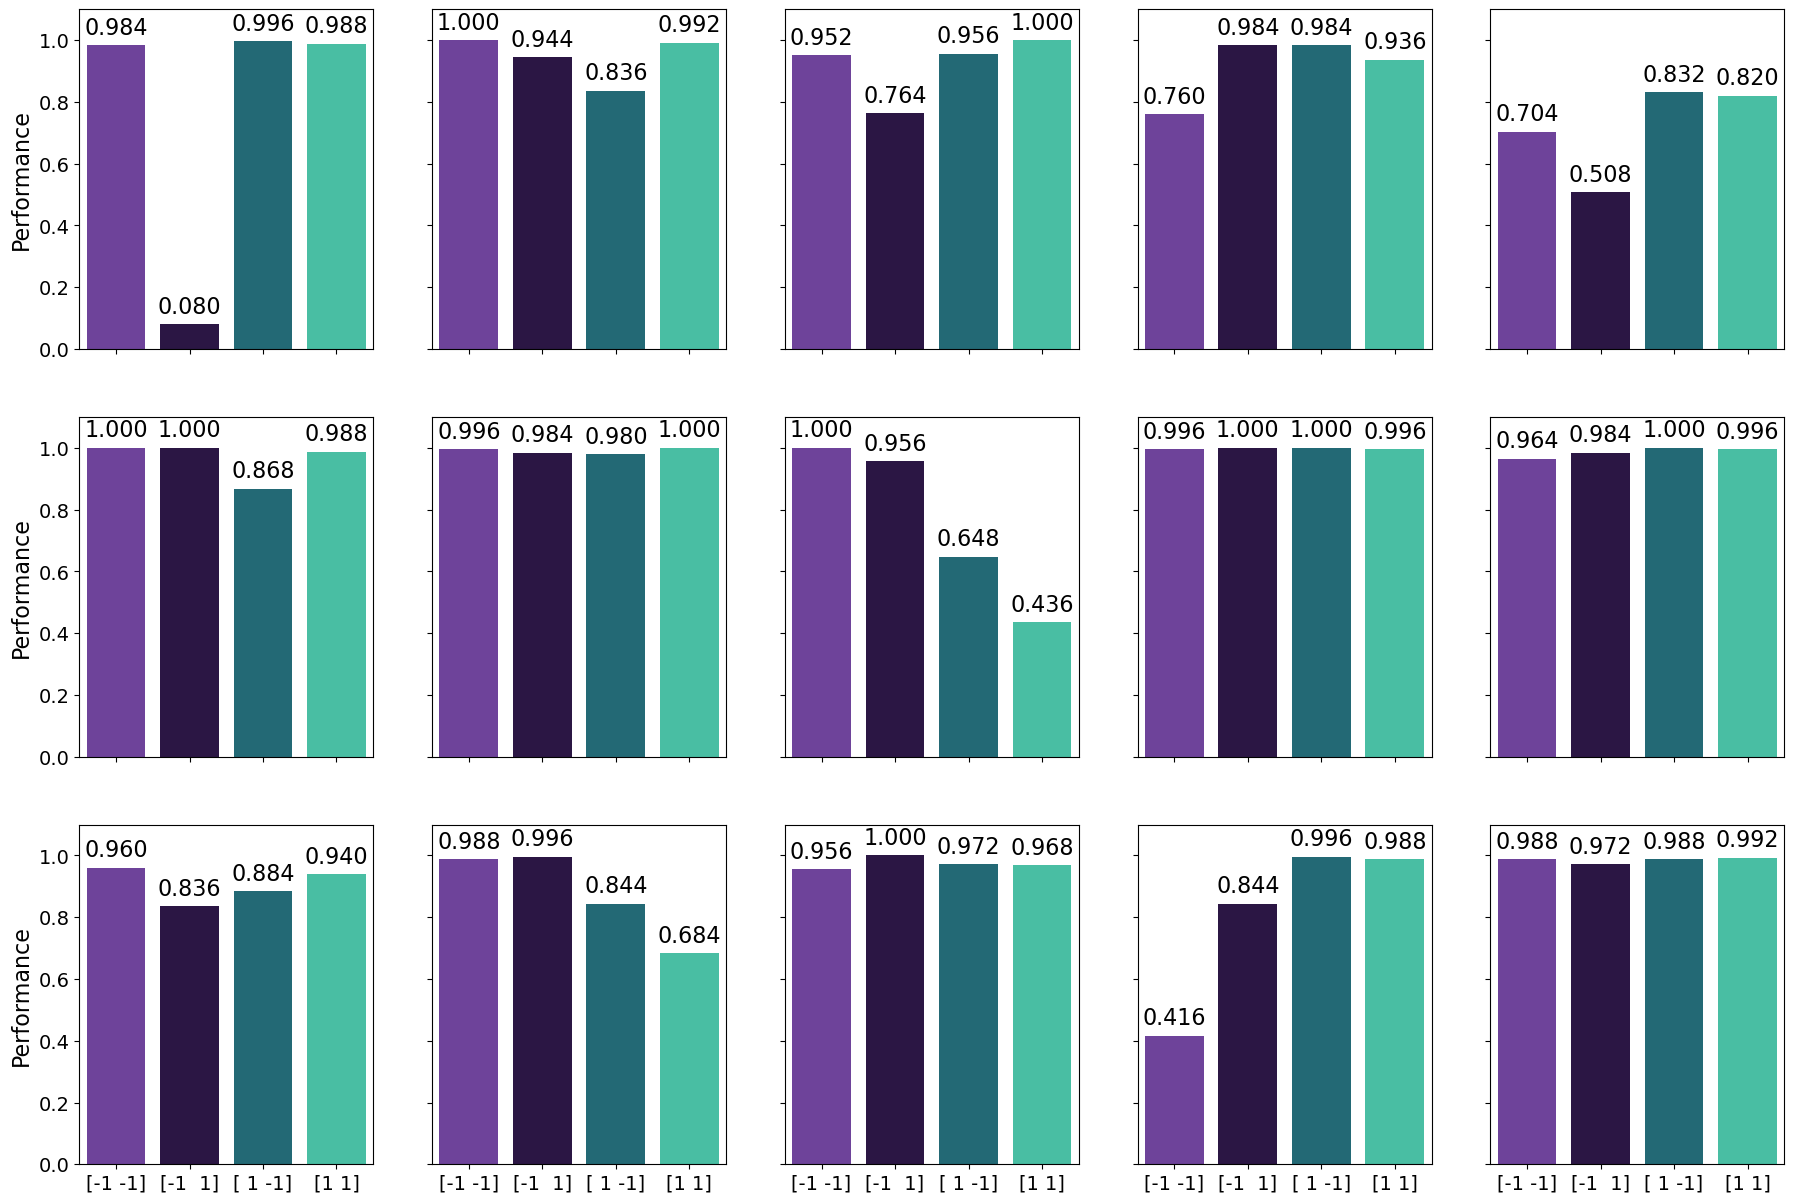

In [16]:
importlib.reload(bhv)

# make all font sizes larger
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(3, 5, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(jittered_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model],
                               all_models_dir=all_models_dir)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
    axs[i].set_title('')
    
# fig.suptitle(f'Jittered Models Performance for {condn_phrase} {condn_num}', fontsize=20)
plt.show()

### delay 50

In [19]:
delay = 50
condn_phrase = 'delay'
condn_num = delay

In [20]:
# find folder names within model directory
# all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
all_models_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [21]:
# get all of the jittered models and their performances
importlib.reload(ld)
jittered_models, jittered_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              all_models_dir = all_models_dir)


Found 15 models with performance between -inf and inf


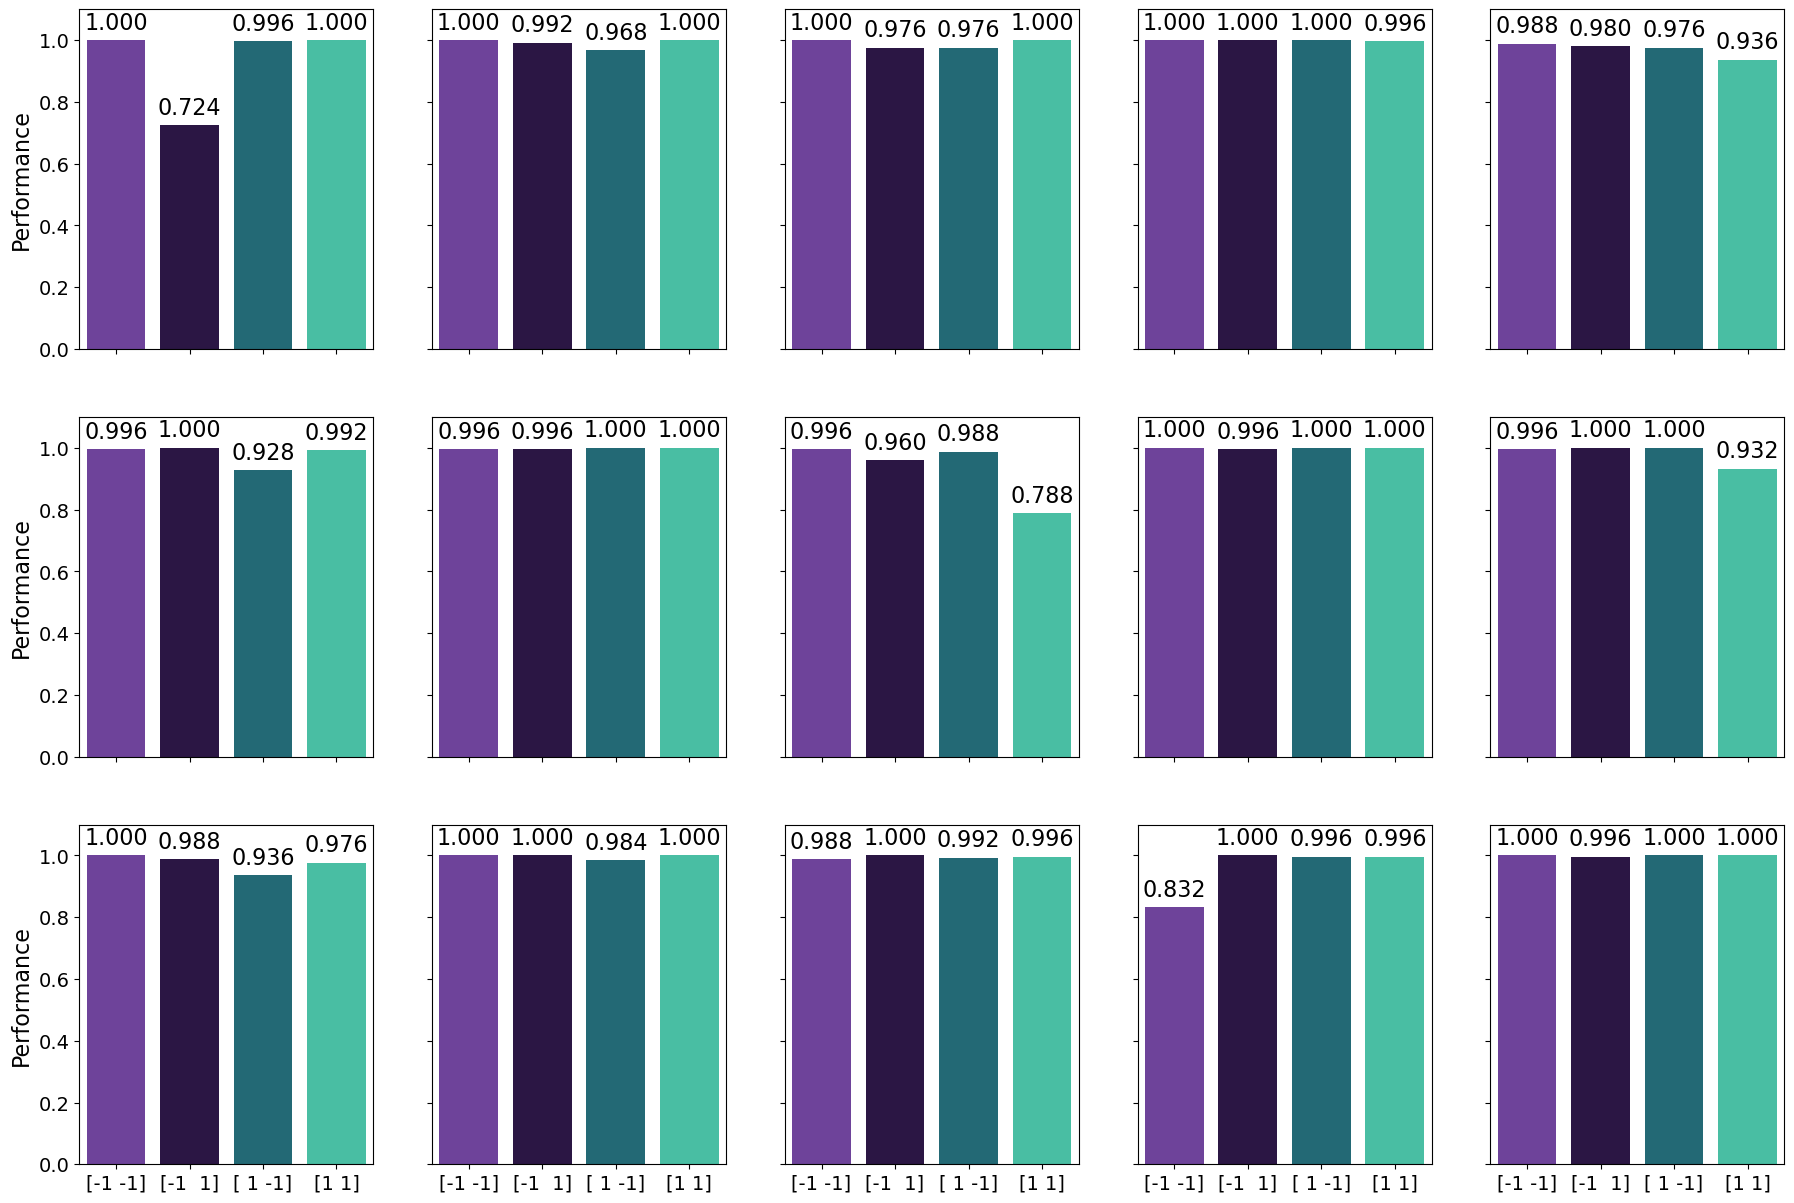

In [22]:
importlib.reload(bhv)

# make all font sizes larger
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(3, 5, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(jittered_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model],
                               all_models_dir=all_models_dir)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
    axs[i].set_title('')
    
# fig.suptitle(f'Jittered Models Performance for {condn_phrase} {condn_num}', fontsize=20)
plt.show()

### compare delay50 and delay150

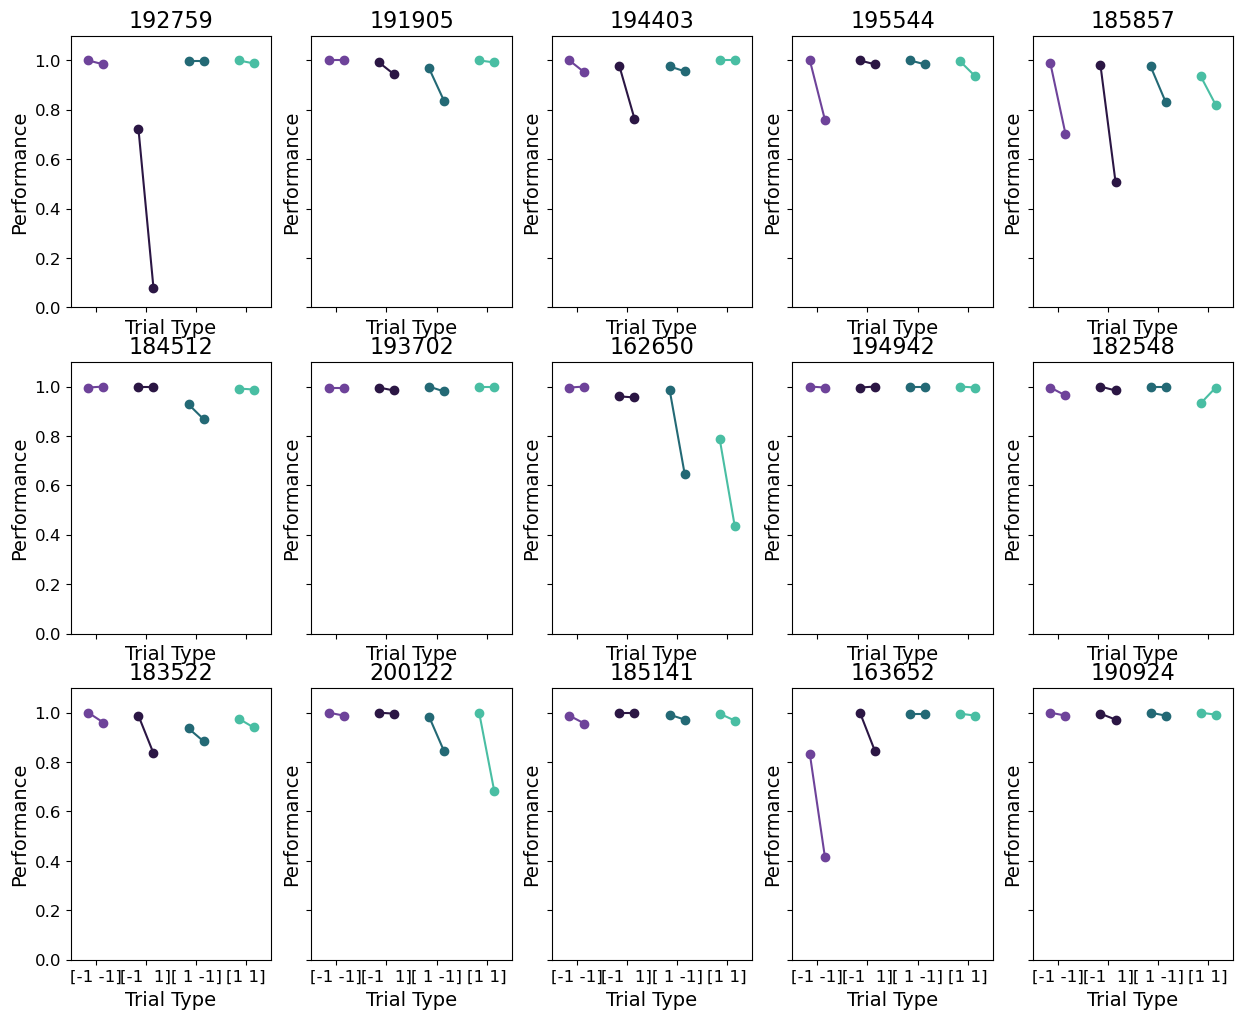

In [28]:
# plot paired comparison of performance for delay=50 and delay=150
importlib.reload(bhv)
fig, axs = plt.subplots(3, 5, figsize=(15, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(jittered_models):
    bhv.plot_paired_trial_performance(model_name, 'delay', 50, 'delay', 150,
                                axs[i_model], title=model_name[-6:], all_models_dir=all_models_dir,
                                text=False)

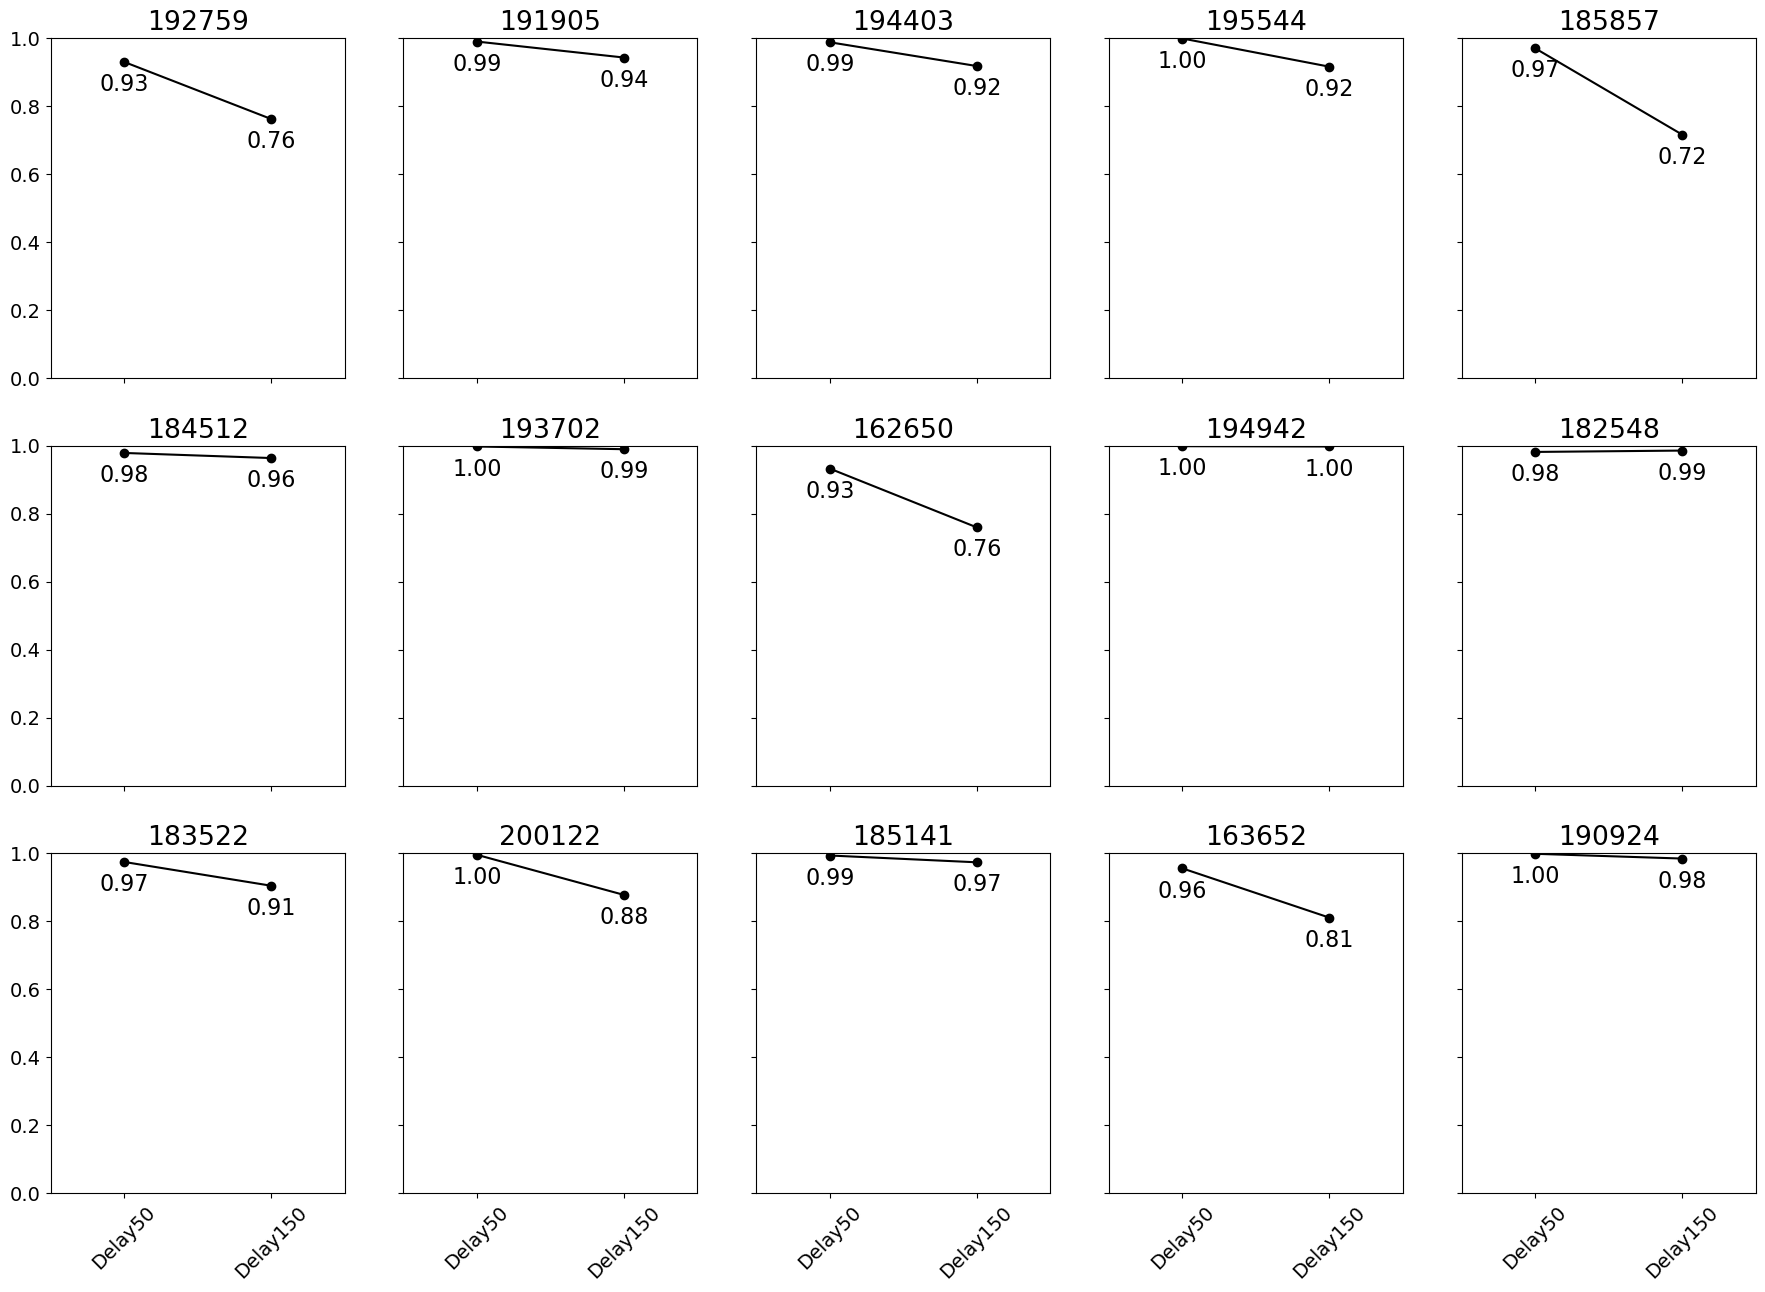

In [9]:
# plot changes in overall model performance

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
fig, axs = plt.subplots(3, 5, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(jittered_models):
    _, trial_perfs_50 = ld.load_bhv_data(model_name, 'delay', 50, all_models_dir=all_models_dir)
    _, trial_perfs_150 = ld.load_bhv_data(model_name, 'delay', 150, all_models_dir=all_models_dir)
    axs[i_model].plot([1.25,1.75], [trial_perfs_50.mean(), trial_perfs_150.mean()],
             marker='o', color='black', label=model_name[-6:])
    axs[i_model].text(1.25, trial_perfs_50.mean() - 0.1,
             f'{trial_perfs_50.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.75, trial_perfs_150.mean() - 0.1,
             f'{trial_perfs_150.mean():.2f}', ha='center', va='bottom')
    axs[i_model].set_title(model_name[-6:])
    axs[i_model].set_ylim(0, 1.0)
    axs[i_model].set_xlim(1, 2)
    axs[i_model].set_xticks([1.25, 1.75])
    axs[i_model].set_xticklabels(['Delay50', 'Delay150'], rotation=45)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
plt.show()